### This notebook will examine how much similar are L2reg and NNLS models and predictions

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cortico_cereb_connectivity.globals as gl
import cortico_cereb_connectivity.summarize as ccs
import cortico_cereb_connectivity.evaluation as ev
from mpl_toolkits.axes_grid1 import make_axes_locatable

/home/UWO/ashahb7/Documents/cortico/lib/python3.8/site-packages/torch/cuda/__init__.py:128: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11060). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0
/home/UWO/ashahb7/Documents/cortico/lib/python3.8/site-packages/torch/__init__.py:955: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at ../torch/csrc/tensor/python_tensor.cpp:432.)
  _C._set_default_tensor_type(t)


In [4]:
def scatter_plot_with_marginals(x, y, t, title, R, margin=False):
    ax = plt.subplot(3, 3, t+1)
    ax.scatter(x, y, s=4, alpha=0.1, color='black')

    if margin:
        divider = make_axes_locatable(ax)
        ax_histx = divider.append_axes("top", size="25%", pad=0.1, sharex=ax)
        ax_histy = divider.append_axes("right", size="25%", pad=0.1, sharey=ax)

        ax_histx.hist(x, bins=50, color='gray', alpha=0.6, log=True)
        ax_histy.hist(y, bins=50, orientation='horizontal', color='gray', alpha=0.6, log=True)

        # tidy up marginal axes
        ax_histx.xaxis.set_tick_params(labelbottom=False)
        ax_histy.yaxis.set_tick_params(labelleft=False)

        # keep limits consistent
        ax_histx.set_xlim(ax.get_xlim())
        ax_histy.set_ylim(ax.get_ylim())
        ax_histx.set_title(title, pad=6)

    if R is not None:
        ax.text(0.05, 0.95, f'R={R:.2f}', transform=ax.transAxes, 
                verticalalignment='top', fontsize=10)

    if t>=6:
        ax.set_xlabel('NNLS coefficients')
    if t%3==0:
        ax.set_ylabel('L2reg coefficients')
    if not margin:
        ax.set_title(title)

#### Load group models

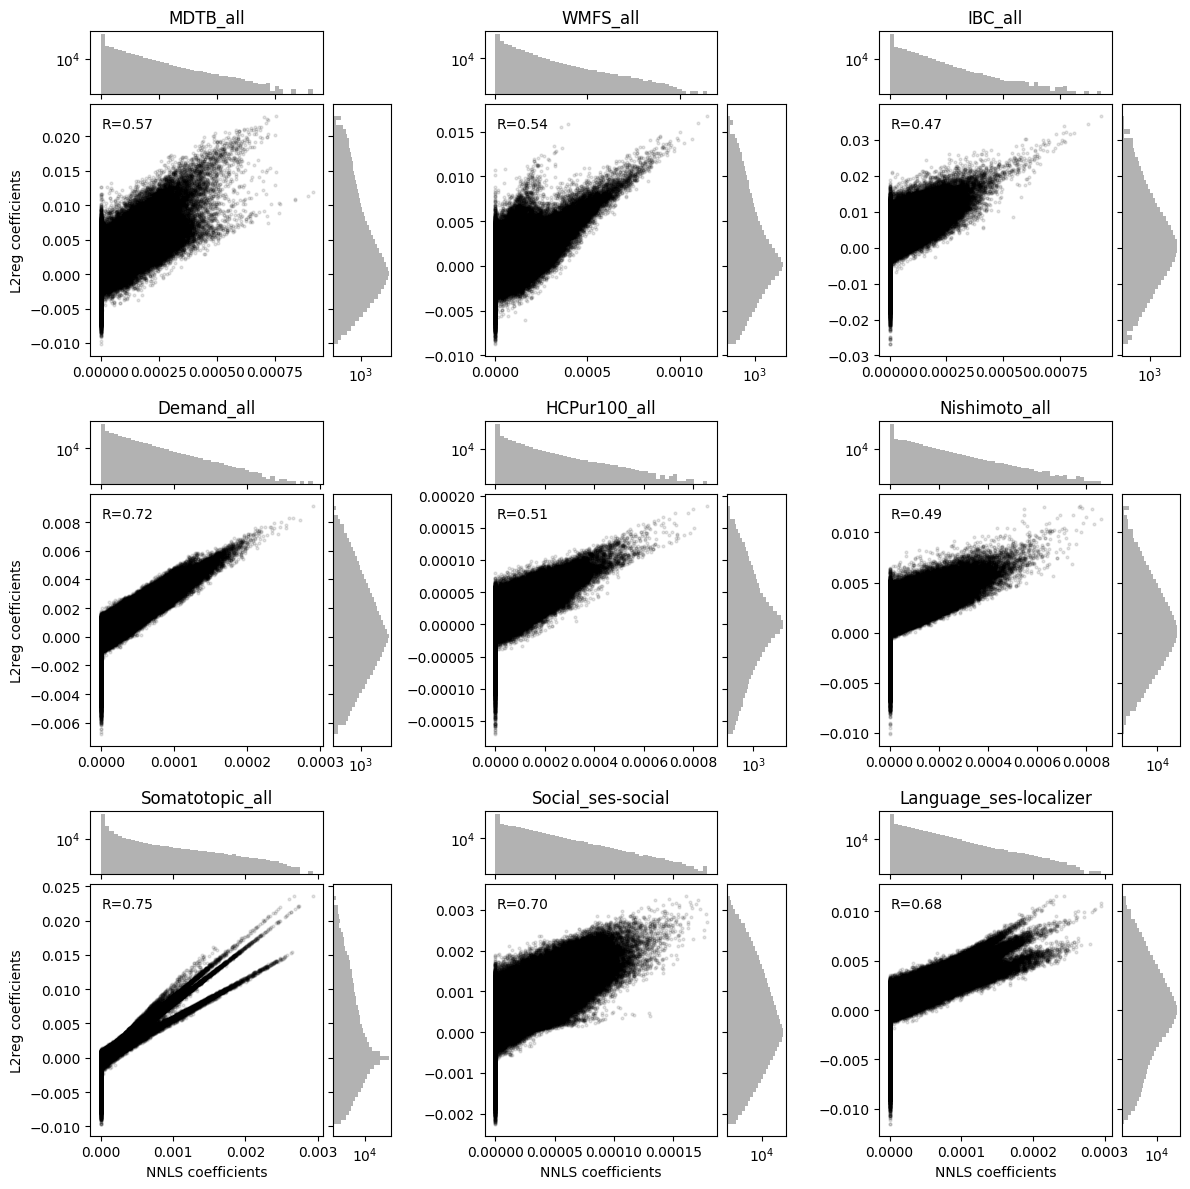

In [5]:
train_ds_list = [ds+"_"+ses for ds, ses in zip(gl.datasets, gl.sessions)]

extention_list_1 = ["A0", "A0", "A0", "A2", "A0", "A0", "A0", "A2", "A2"]
extention_list_2 = ["A6", "A6", "A6", "A6", "A2", "A8", "A8", "A8", "A6"]
plt.subplots(3, 3, figsize=(12, 12), tight_layout=True)#, sharex=True, sharey=True)
for t, (traindata, ext1, ext2) in enumerate(zip(train_ds_list, extention_list_1, extention_list_2)):
    model_NNLS, _ = ccs.get_model(traindata, 'Icosahedron1002', 'NNLS', ext1+"_group", cerebellum_atlas="MNISymC3")
    model_L2reg, _ = ccs.get_model(traindata, 'Icosahedron1002', 'L2reg', ext2+"_group", cerebellum_atlas="MNISymC3")

    R, _ = ev.calculate_R(model_NNLS.coef_, model_L2reg.coef_)
    scatter_plot_with_marginals(model_NNLS.coef_.flatten(), model_L2reg.coef_.flatten(), t, f'{traindata}', R, margin=True)

#### Load global models

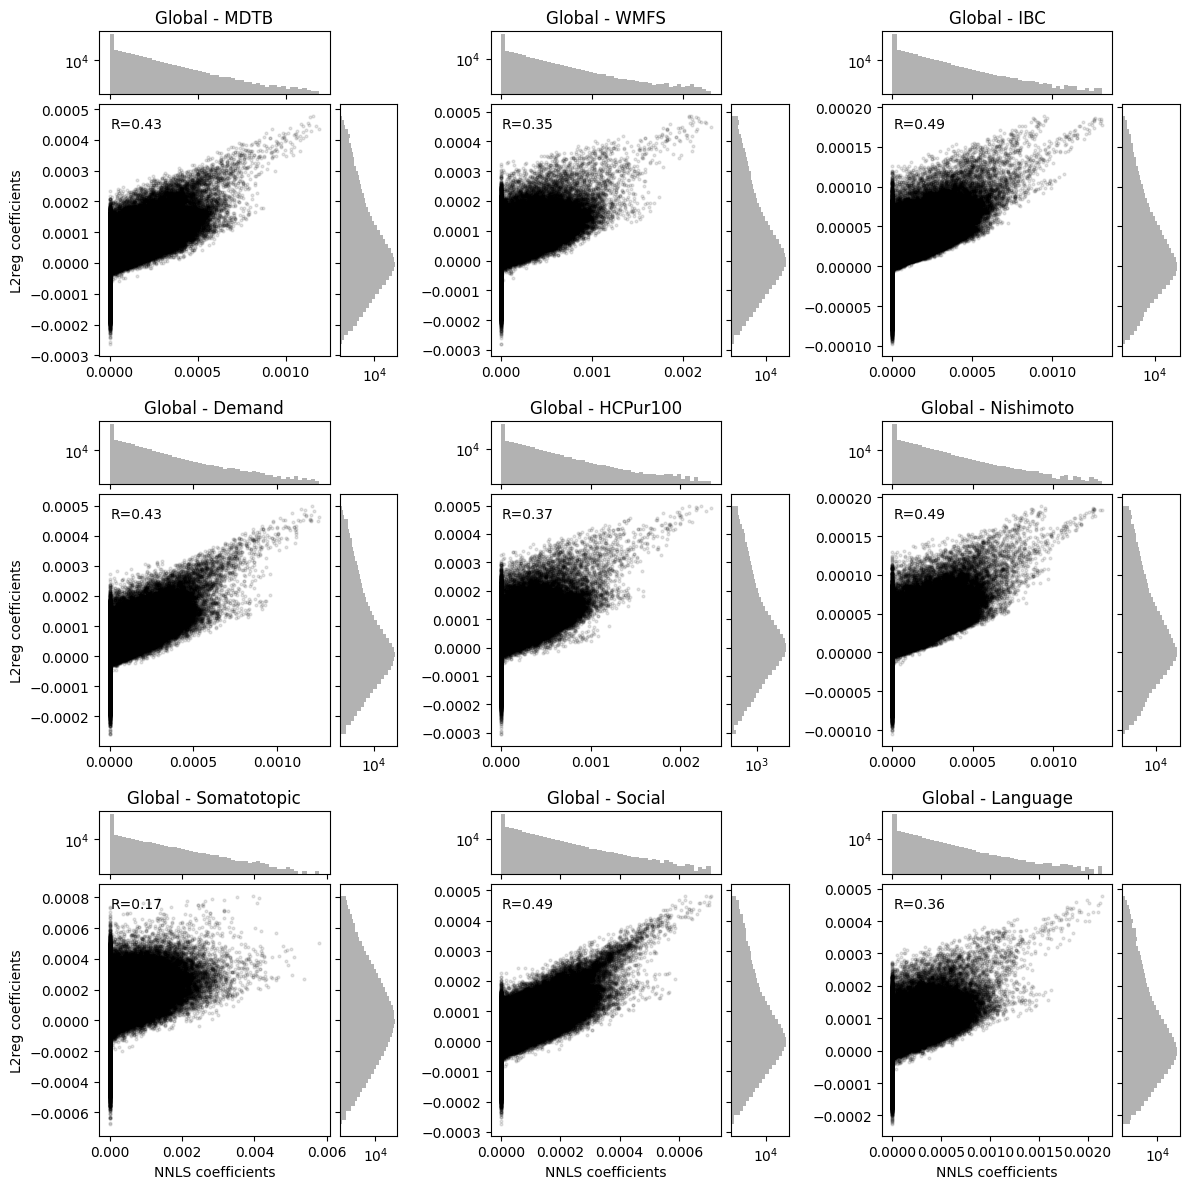

In [6]:
train_ds_list = gl.get_ldo_names()
eval_ds_list = gl.datasets

extention_list_1 = ["A1", "A0", "A1", "A1", "A0", "A1", "", "A2", "A0"]
extention_list_2 = ["A2", "A2", "A4", "A2", "A2", "A4", "", "A2", "A2"]
plt.subplots(3, 3, figsize=(12, 12), tight_layout=True)#, sharex=True, sharey=True)
for t, (traindata, ext1, ext2, ev_ds) in enumerate(zip(train_ds_list, extention_list_1, extention_list_2, eval_ds_list)):
    if ext1 != "":
        model_NNLS, _ = ccs.get_model(traindata, 'Icosahedron1002', 'NNLS', ext1+"_global", cerebellum_atlas="MNISymC3")
    else:
        model_NNLS, _ = ccs.get_model(traindata, 'Icosahedron1002', 'NNLS', "global", cerebellum_atlas="MNISymC3")
    
    if ext2 != "":
        model_L2reg, _ = ccs.get_model(traindata, 'Icosahedron1002', 'L2reg', ext2+"_global", cerebellum_atlas="MNISymC3")
    else:
        model_L2reg, _ = ccs.get_model(traindata, 'Icosahedron1002', 'L2reg', "global", cerebellum_atlas="MNISymC3")

    R, _ = ev.calculate_R(model_NNLS.coef_, model_L2reg.coef_)
    scatter_plot_with_marginals(model_NNLS.coef_.flatten(), model_L2reg.coef_.flatten(), t, f'Global - {ev_ds}', R, margin=True)